# Forward Neural Network

## Overview of Requirements

Goal: Classify movement data using RNNs (GRUs) instead of feedforward networks.
Core idea: You’ll take the same accelerometer + gyroscope data you’ve been using, but now process it as time-series sequences, not just feature vectors.

Gated Recurrent Unit
Gated Recurrent Unit (GRU) is defined as a type of recurrent neural network (RNN) architecture designed to capture dependencies in sequential data while addressing the vanishing gradient problem. It features a simpler structure than LSTMs, utilizing two gating mechanisms—an update gate and a reset gate—to efficiently model temporal dependencies and reduce computational complexity.

## Setup and imports

We import all necessary libraries. TensorFlow will automatically use GPU if available. We set random seeds for reproducibility.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import GRU, LSTM, Dropout, Dense, Input, Bidirectional, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l1, l2, l1_l2
import time

# For reproducibility
import random
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Check GPU availability
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if len(tf.config.list_physical_devices('GPU')) > 0:
    print("GPU is available and will be used for training.")
    print("GPU Details:", tf.config.list_physical_devices('GPU'))
else:
    print("WARNING: No GPU detected. Training will be slower on CPU.")

2025-11-11 09:07:09.767295: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Num GPUs Available:  0


## Load Data

We load the preprocessed data from Labs 1-3. The data is already cleaned with 6 features (ax, ay, az, gx, gy, gz) and class labels.

In [2]:
print("\n" + "="*80)
print("1. DATA LOADING AND PREPROCESSING")
print("="*80)

# Define your classes (Elina)
my_classes = ['p1_jumping', 'p1_walking', 'p1_running', 'p1_stairs']

# Define Person 2's classes (Person 2)
p2_classes = ['p2_running', 'p2_walking', 'p2_jumping', 'p2_squatting']

# Load your data
print("\nLoading my data...")
my_train_df = pd.read_pickle('../pickles/train_df.pkl')
my_valid_df = pd.read_pickle('../pickles/valid_df.pkl')
my_test_df = pd.read_pickle('../pickles/test_df.pkl')

print(f"  Train: {my_train_df.shape}")
print(f"  Valid: {my_valid_df.shape}")
print(f"  Test: {my_test_df.shape}")
print(f"  Classes: {my_train_df['class'].unique()}")

# Load Person 2's data
print("\nLoading Person 2's data...")
p2_train_df = pd.read_pickle('../pickles/train_df_p2.pkl')
p2_valid_df = pd.read_pickle('../pickles/valid_df_p2.pkl')
p2_test_df = pd.read_pickle('../pickles/test_df_p2.pkl')

# Normalize case to lowercase
p2_train_df['class'] = p2_train_df['class'].str.lower()
p2_valid_df['class'] = p2_valid_df['class'].str.lower()
p2_test_df['class'] = p2_test_df['class'].str.lower()

print(f"  Train: {p2_train_df.shape}")
print(f"  Valid: {p2_valid_df.shape}")
print(f"  Test: {p2_test_df.shape}")
print(f"  Classes: {p2_train_df['class'].unique()}")

# Add person identifier to create 8-class labels
print("\nCreating 8-class combined dataset...")
my_train_df['class_combined'] = 'p1_' + my_train_df['class']
my_valid_df['class_combined'] = 'p1_' + my_valid_df['class']
my_test_df['class_combined'] = 'p1_' + my_test_df['class']

p2_train_df['class_combined'] = 'p2_' + p2_train_df['class']
p2_valid_df['class_combined'] = 'p2_' + p2_valid_df['class']
p2_test_df['class_combined'] = 'p2_' + p2_test_df['class']

# Combine datasets
train_df_combined = pd.concat([my_train_df, p2_train_df], ignore_index=True)
valid_df_combined = pd.concat([my_valid_df, p2_valid_df], ignore_index=True)
test_df_combined = pd.concat([my_test_df, p2_test_df], ignore_index=True)

print("\n=== Combined Dataset Statistics ===")
print(f"Train: {train_df_combined.shape[0]} samples")
print(f"Valid: {valid_df_combined.shape[0]} samples")
print(f"Test: {test_df_combined.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(train_df_combined['class_combined'].value_counts().sort_index())

# Extract features and labels
X_train = train_df_combined.drop(['class', 'class_combined'], axis=1).values
y_train = train_df_combined['class_combined'].values

X_valid = valid_df_combined.drop(['class', 'class_combined'], axis=1).values
y_valid = valid_df_combined['class_combined'].values

X_test = test_df_combined.drop(['class', 'class_combined'], axis=1).values
y_test = test_df_combined['class_combined'].values

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape} (samples, features)")
print(f"  X_valid: {X_valid.shape}")
print(f"  X_test: {X_test.shape}")

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_valid_encoded = le.transform(y_valid)
y_test_encoded = le.transform(y_test)

print(f"\n=== 8-Class Encoding ===")
for idx, cls in enumerate(le.classes_):
    movement = cls.split('_')[1]
    person = cls.split('_')[0]
    print(f"  {cls}: {idx} (Person {person[-1]}, {movement})")

# Normalize features to [-1, 1] range
print("\nNormalizing features...")
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print(f"  Train - Min: {X_train_scaled.min():.3f}, Max: {X_train_scaled.max():.3f}")
print(f"  Valid - Min: {X_valid_scaled.min():.3f}, Max: {X_valid_scaled.max():.3f}")
print(f"  Test - Min: {X_test_scaled.min():.3f}, Max: {X_test_scaled.max():.3f}")

n_features = X_train_scaled.shape[1]
n_classes = len(le.classes_)
print(f"\nFinal dataset: {n_features} features, {n_classes} classes")


1. DATA LOADING AND PREPROCESSING

Loading my data...
  Train: (23566, 7)
  Valid: (8997, 7)
  Test: (5138, 7)
  Classes: ['jumping' 'walking' 'running' 'stairs']

Loading Person 2's data...
  Train: (34360, 7)
  Valid: (16377, 7)
  Test: (6117, 7)
  Classes: ['jumping' 'running' 'squatting' 'walking']

Creating 8-class combined dataset...

=== Combined Dataset Statistics ===
Train: 57926 samples
Valid: 25374 samples
Test: 11255 samples

Class distribution in training set:
class_combined
p1_jumping      6757
p1_running      5474
p1_stairs       5526
p1_walking      5809
p2_jumping      9062
p2_running      9130
p2_squatting    7501
p2_walking      8667
Name: count, dtype: int64

Feature matrix shapes:
  X_train: (57926, 6) (samples, features)
  X_valid: (25374, 6)
  X_test: (11255, 6)

=== 8-Class Encoding ===
  p1_jumping: 0 (Person 1, jumping)
  p1_running: 1 (Person 1, running)
  p1_stairs: 2 (Person 1, stairs)
  p1_walking: 3 (Person 1, walking)
  p2_jumping: 4 (Person 2, jumping)

## Helper Functions

### Create Sequences for RNN

RNNs need 3D input (samples, timesteps, features). This function creates sliding windows over your time series. The step parameter controls overlap - smaller step means more overlap and more training samples.

In [3]:
def create_sequences(X, y, window_size=50, step=25):
    """
    Convert flat time series into overlapping windows for RNN input.
    
    RNNs require 3D input: (samples, timesteps, features)
    This function creates sliding windows over the time series.
    
    Parameters:
    -----------
    X : array, shape (n_samples, n_features) - Feature data
    y : array, shape (n_samples,) - Labels
    window_size : int - Number of timesteps in each sequence
    step : int - Step size between windows (smaller = more overlap)
    
    Returns:
    --------
    X_seq : array, shape (n_windows, window_size, n_features) - 3D array for RNN input
    y_seq : array, shape (n_windows,) - Labels for each window
    """
    Xs, ys = [], []
    for start in range(0, len(X) - window_size + 1, step):
        end = start + window_size
        Xs.append(X[start:end])
        # Use label from middle of window
        ys.append(y[start + window_size // 2])
    return np.array(Xs), np.array(ys)


### Visualization Functions

In [4]:
def plot_training_history(history, title="Training History"):
    """Plot training and validation metrics."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Training', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title(f'{title} - Accuracy', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Loss
    ax2.plot(history.history['loss'], label='Training', linewidth=2, color='orange')
    ax2.plot(history.history['val_loss'], label='Validation', linewidth=2, color='red')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title(f'{title} - Loss', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [5]:
def plot_confusion_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    """Plot confusion matrix with classification report."""
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=True)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    print(f"\n{title}")
    print("="*80)
    print(classification_report(y_true, y_pred, target_names=classes))

### Model Building Function

In [6]:
def build_gru_model(window_size, n_features, n_classes, 
                    n_layers=1, n_units=64, 
                    dropout_rate=0.3, learning_rate=0.001,
                    bidirectional=False, l2_reg=0.0):
    """
    Build GRU model with comprehensive hyperparameters.
    
    Architecture:
    - Input: (window_size, n_features)
    - GRU layers with optional bidirectional processing
    - Dropout for regularization
    - Dense output with softmax for classification
    
    Hyperparameters:
    ----------------
    window_size : int - Sequence length
    n_features : int - Number of input features (6 for accelerometer + gyro)
    n_classes : int - Number of output classes (8 for grade 5)
    n_layers : int - Number of stacked GRU layers (1 or 2)
    n_units : int - Hidden units per GRU layer (32, 64, 128)
    dropout_rate : float - Dropout probability (0.2, 0.3, 0.5)
    learning_rate : float - Adam optimizer learning rate (0.0001, 0.0005, 0.001)
    bidirectional : bool - Use bidirectional GRU (processes sequence both ways)
    l2_reg : float - L2 regularization coefficient (0, 0.001, 0.01)
    
    Returns:
    --------
    Compiled Keras model
    """
    inputs = Input(shape=(window_size, n_features), name='input')
    x = inputs
    
    # Stack GRU layers
    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)  # All but last layer return sequences
        
        gru_layer = GRU(
            units=n_units,
            return_sequences=return_sequences,
            kernel_regularizer=l2(l2_reg) if l2_reg > 0 else None,
            recurrent_regularizer=l2(l2_reg) if l2_reg > 0 else None,
            name=f'gru_layer_{i+1}'
        )
        
        # Optional bidirectional wrapper
        if bidirectional:
            x = Bidirectional(gru_layer, name=f'bidirectional_gru_{i+1}')(x)
        else:
            x = gru_layer(x)
        
        # Dropout for regularization
        if dropout_rate > 0:
            x = Dropout(dropout_rate, name=f'dropout_{i+1}')(x)
    
    # Output layer
    outputs = Dense(n_classes, activation='softmax', name='output')(x)
    
    # Build and compile model
    model = keras.Model(inputs=inputs, outputs=outputs, name='GRU_Classifier')
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

## Basic GRU Classification

This trains all 18 model combinations. EarlyStopping stops training when validation loss stops improving, preventing overfitting.

### Hyperparameter Search Configuration

In [7]:
hyperparameter_grid = {
    # Core architecture (Grade 3 requirements)
    'n_layers': [1, 2],                    # Number of GRU layers
    'n_units': [32, 64, 128],              # Units per layer
    'window_size': [30, 50, 75],           # Sequence length
    
    # Advanced hyperparameters (Grade 4 requirements)
    'dropout_rate': [0.2, 0.3, 0.5],       # Regularization via dropout
    'learning_rate': [0.0001, 0.0005, 0.001],  # Optimizer learning rate
    'bidirectional': [False, True],         # Bidirectional processing
    'l2_reg': [0.0, 0.001, 0.01]           # L2 weight regularization
}

# For practical reasons, we'll test strategic combinations
# rather than full grid (which would be 2*3*3 * 3*3*2*3 = 972 combinations!)

print("\n=== Hyperparameter Search Strategy ===")
print("\nWe'll use a two-stage approach:")
print("1. Stage 1: Find best basic architecture (layers, units, window_size)")
print("2. Stage 2: Optimize advanced hyperparameters around best architecture")

# Stage 1: Basic architecture search (Grade 3)
stage1_configs = []
for n_layers in hyperparameter_grid['n_layers']:
    for n_units in hyperparameter_grid['n_units']:
        for window_size in hyperparameter_grid['window_size']:
            stage1_configs.append({
                'window_size': window_size,
                'n_features': n_features,
                'n_classes': n_classes,
                'n_layers': n_layers,
                'n_units': n_units,
                'dropout_rate': 0.3,        # Default
                'learning_rate': 0.001,      # Default
                'bidirectional': False,      # Default
                'l2_reg': 0.0               # Default
            })

print(f"\nStage 1: {len(stage1_configs)} configurations (Grade 3 requirement: 2×3×3 = 18)")

# Stage 2: We'll create these after Stage 1 completes
print("\nStage 2: Will test ~10-12 advanced configurations")
print("  - Varying dropout_rate")
print("  - Varying learning_rate")
print("  - Testing bidirectional=True")
print("  - Testing l2_reg values")


=== Hyperparameter Search Strategy ===

We'll use a two-stage approach:
1. Stage 1: Find best basic architecture (layers, units, window_size)
2. Stage 2: Optimize advanced hyperparameters around best architecture

Stage 1: 18 configurations (Grade 3 requirement: 2×3×3 = 18)

Stage 2: Will test ~10-12 advanced configurations
  - Varying dropout_rate
  - Varying learning_rate
  - Testing bidirectional=True
  - Testing l2_reg values


### Cross-Validation Framework

Why Cross-Validation?
    - More robust performance estimate than single train/val split
    - Required for Grade 4
    - Uses all data for both training and validation

In [8]:
def cross_validate_model(X, y, model_params, n_folds=5, epochs=50, batch_size=32, verbose=True):
    """
    Perform k-fold cross-validation on combined train+valid data.
    
    Process:
    1. Split data into k folds
    2. For each fold:
       - Train on k-1 folds
       - Validate on remaining fold
    3. Average results across all folds
    
    Parameters:
    -----------
    X : array, shape (n_samples, window_size, n_features)
    y : array, shape (n_samples,)
    model_params : dict - Model configuration
    n_folds : int - Number of CV folds (5 is standard)
    
    Returns:
    --------
    dict with mean_acc, std_acc, fold_scores, and training time
    """
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    
    fold_scores = []
    fold_histories = []
    fold_times = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X), 1):
        if verbose:
            print(f"  Fold {fold}/{n_folds}...", end=" ", flush=True)
        
        X_train_fold = X[train_idx]
        X_val_fold = X[val_idx]
        y_train_fold = y[train_idx]
        y_val_fold = y[val_idx]
        
        # Build fresh model for this fold
        model = build_gru_model(**model_params)
        
        # Callbacks for training optimization
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                verbose=0
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=0
            )
        ]
        
        # Train
        start_time = time.time()
        history = model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=0
        )
        fold_time = time.time() - start_time
        
        # Evaluate on validation fold
        val_loss, val_acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
        
        fold_scores.append(val_acc)
        fold_histories.append(history)
        fold_times.append(fold_time)
        
        if verbose:
            print(f"Acc: {val_acc:.4f} ({fold_time:.1f}s)")
    
    return {
        'mean_acc': np.mean(fold_scores),
        'std_acc': np.std(fold_scores),
        'fold_scores': fold_scores,
        'fold_histories': fold_histories,
        'total_time': np.sum(fold_times)
    }

### Basic Architecture Search

In [9]:
print("\n" + "="*80)
print("BASIC ARCHITECTURE SEARCH")
print("="*80)
print("Testing 18 configurations")
print("Using 5-fold cross-validation")
print("="*80)

# Combine train and valid for cross-validation
X_train_valid = np.concatenate([X_train_scaled, X_valid_scaled])
y_train_valid = np.concatenate([y_train_encoded, y_valid_encoded])

print(f"\nCombined train+valid data: {X_train_valid.shape[0]} samples")

stage1_results = []

for config_idx, config in enumerate(stage1_configs, 1):
    print(f"\n[Config {config_idx}/{len(stage1_configs)}]")
    print(f"  Layers: {config['n_layers']}, Units: {config['n_units']}, Window: {config['window_size']}")
    
    # Create sequences for this window size
    ws = config['window_size']
    X_seq, y_seq = create_sequences(X_train_valid, y_train_valid, window_size=ws)
    print(f"  Sequences: {X_seq.shape}")
    
    # Run cross-validation
    cv_results = cross_validate_model(X_seq, y_seq, config, n_folds=5)
    
    # Store results
    result = {
        **config,
        'cv_mean_acc': cv_results['mean_acc'],
        'cv_std_acc': cv_results['std_acc'],
        'cv_fold_scores': cv_results['fold_scores'],
        'cv_time': cv_results['total_time']
    }
    stage1_results.append(result)
    
    print(f"  → CV Accuracy: {cv_results['mean_acc']:.4f} ± {cv_results['std_acc']:.4f}")
    print(f"  → Time: {cv_results['total_time']:.1f}s")


BASIC ARCHITECTURE SEARCH
Testing 18 configurations
Using 5-fold cross-validation

Combined train+valid data: 83300 samples

[Config 1/18]
  Layers: 1, Units: 32, Window: 30
  Sequences: (3331, 30, 6)
  Fold 1/5... Acc: 0.9250 (26.4s)
  Fold 2/5... Acc: 0.9144 (24.4s)
  Fold 3/5... Acc: 0.9324 (24.0s)
  Fold 4/5... Acc: 0.9159 (24.1s)
  Fold 5/5... Acc: 0.9264 (24.5s)
  → CV Accuracy: 0.9228 ± 0.0068
  → Time: 123.4s

[Config 2/18]
  Layers: 1, Units: 32, Window: 50
  Sequences: (3331, 50, 6)
  Fold 1/5... Acc: 0.9640 (35.2s)
  Fold 2/5... Acc: 0.9655 (55.1s)
  Fold 3/5... Acc: 0.9745 (42.4s)
  Fold 4/5... Acc: 0.9685 (41.5s)
  Fold 5/5... Acc: 0.9505 (40.7s)
  → CV Accuracy: 0.9646 ± 0.0079
  → Time: 214.8s

[Config 3/18]
  Layers: 1, Units: 32, Window: 75
  Sequences: (3330, 75, 6)
  Fold 1/5... Acc: 0.9760 (56.2s)
  Fold 2/5... Acc: 0.9745 (57.3s)
  Fold 3/5... Acc: 0.9580 (58.8s)
  Fold 4/5... Acc: 0.9655 (53.8s)
  Fold 5/5... Acc: 0.9640 (51.3s)
  → CV Accuracy: 0.9676 ± 0.0068
 

### Analyze Stage 1 Results


STAGE 1 RESULTS ANALYSIS

=== Top 10 Configurations ===
 n_layers  n_units  window_size  cv_mean   cv_std     time_s
        2      128           75 0.994294 0.002207 858.226205
        2       64           75 0.990691 0.002402 657.840443
        2       32           75 0.988889 0.004515 500.152552
        2      128           50 0.988593 0.003089 590.389488
        1      128           75 0.988589 0.006552 889.288563
        1       64           75 0.987688 0.004691 288.355509
        2       64           50 0.986491 0.004139 438.438299
        1      128           50 0.981989 0.003545 308.572380
        2      128           30 0.981987 0.007043 546.114528
        1       64           50 0.978384 0.005257 197.870015

=== Best Stage 1 Configuration ===
Layers: 1
Units: 32
Window Size: 30
CV Accuracy: 0.9228 ± 0.0068
Training Time: 123.4s


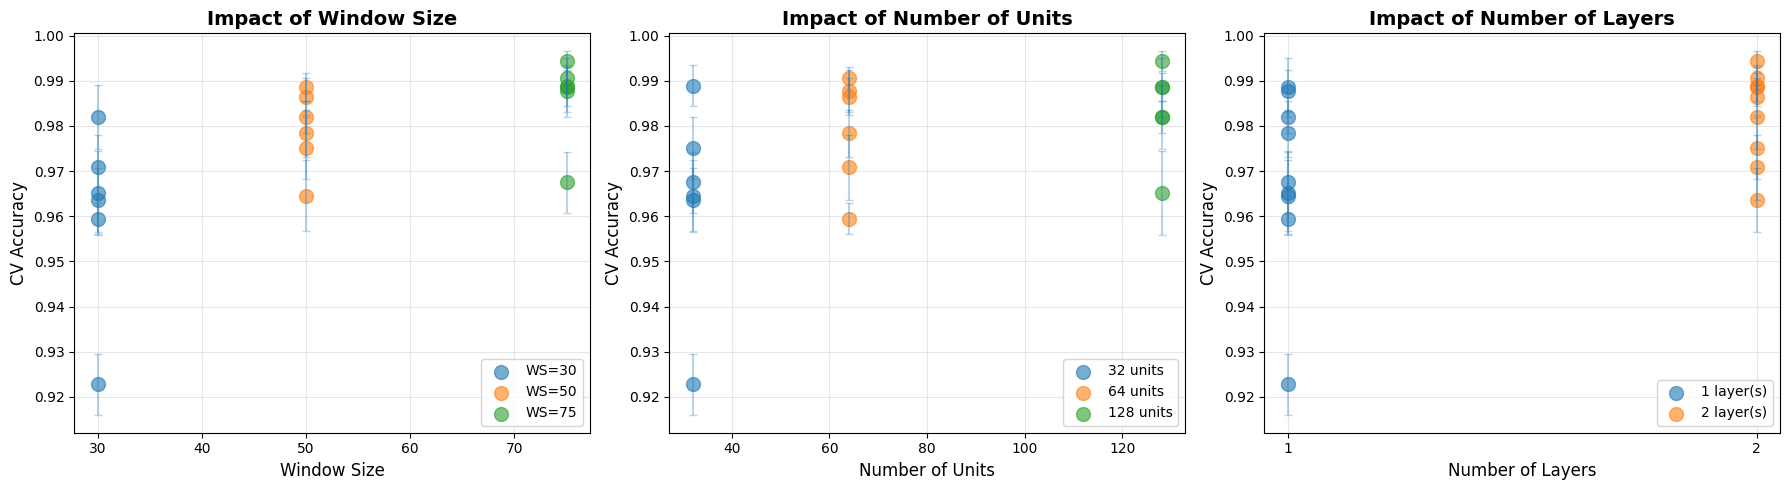


=== Hyperparameter Sensitivity ===

Window Size:
                 mean       std       max
window_size                              
30           0.960674  0.020101  0.981987
50           0.979186  0.008725  0.988593
75           0.986286  0.009465  0.994294

Number of Units:
             mean       std       max
n_units                              
32       0.963773  0.022131  0.988889
64       0.978934  0.011966  0.990691
128      0.983439  0.010085  0.994294

Number of Layers:
              mean       std       max
n_layers                              
1         0.968477  0.020139  0.988589
2         0.982287  0.010273  0.994294


In [10]:
print("\n" + "="*80)
print("STAGE 1 RESULTS ANALYSIS")
print("="*80)

# Create results dataframe
stage1_df = pd.DataFrame([{
    'n_layers': r['n_layers'],
    'n_units': r['n_units'],
    'window_size': r['window_size'],
    'cv_mean': r['cv_mean_acc'],
    'cv_std': r['cv_std_acc'],
    'time_s': r['cv_time']
} for r in stage1_results])

# Sort by CV mean accuracy
stage1_df = stage1_df.sort_values('cv_mean', ascending=False)

print("\n=== Top 10 Configurations ===")
print(stage1_df.head(10).to_string(index=False))

# Find best configuration
best_stage1_idx = stage1_df.index[0]
best_stage1_config = stage1_results[stage1_df.index.tolist().index(best_stage1_idx)]

print(f"\n=== Best Stage 1 Configuration ===")
print(f"Layers: {best_stage1_config['n_layers']}")
print(f"Units: {best_stage1_config['n_units']}")
print(f"Window Size: {best_stage1_config['window_size']}")
print(f"CV Accuracy: {best_stage1_config['cv_mean_acc']:.4f} ± {best_stage1_config['cv_std_acc']:.4f}")
print(f"Training Time: {best_stage1_config['cv_time']:.1f}s")

# Visualize hyperparameter effects
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Window size effect
for ws in [30, 50, 75]:
    subset = stage1_df[stage1_df['window_size'] == ws]
    axes[0].scatter([ws]*len(subset), subset['cv_mean'], alpha=0.6, s=100, label=f'WS={ws}')
    axes[0].errorbar([ws]*len(subset), subset['cv_mean'], yerr=subset['cv_std'], 
                     fmt='none', alpha=0.3, capsize=3)
axes[0].set_xlabel('Window Size', fontsize=12)
axes[0].set_ylabel('CV Accuracy', fontsize=12)
axes[0].set_title('Impact of Window Size', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Number of units effect
for units in [32, 64, 128]:
    subset = stage1_df[stage1_df['n_units'] == units]
    axes[1].scatter([units]*len(subset), subset['cv_mean'], alpha=0.6, s=100, label=f'{units} units')
    axes[1].errorbar([units]*len(subset), subset['cv_mean'], yerr=subset['cv_std'], 
                     fmt='none', alpha=0.3, capsize=3)
axes[1].set_xlabel('Number of Units', fontsize=12)
axes[1].set_ylabel('CV Accuracy', fontsize=12)
axes[1].set_title('Impact of Number of Units', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Number of layers effect
for layers in [1, 2]:
    subset = stage1_df[stage1_df['n_layers'] == layers]
    axes[2].scatter([layers]*len(subset), subset['cv_mean'], alpha=0.6, s=100, label=f'{layers} layer(s)')
    axes[2].errorbar([layers]*len(subset), subset['cv_mean'], yerr=subset['cv_std'], 
                     fmt='none', alpha=0.3, capsize=3)
axes[2].set_xlabel('Number of Layers', fontsize=12)
axes[2].set_ylabel('CV Accuracy', fontsize=12)
axes[2].set_title('Impact of Number of Layers', fontsize=14, fontweight='bold')
axes[2].set_xticks([1, 2])
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n=== Hyperparameter Sensitivity ===")
print("\nWindow Size:")
print(stage1_df.groupby('window_size')['cv_mean'].agg(['mean', 'std', 'max']))
print("\nNumber of Units:")
print(stage1_df.groupby('n_units')['cv_mean'].agg(['mean', 'std', 'max']))
print("\nNumber of Layers:")
print(stage1_df.groupby('n_layers')['cv_mean'].agg(['mean', 'std', 'max']))

## Advanced Hyperparameter Optimization

In [11]:
print("\n" + "="*80)
print("ADVANCED HYPERPARAMETER OPTIMIZATION")
print("="*80)
print("Testing advanced hyperparameters around best architecture (Grade 4 requirement)")
print("="*80)

# Create Stage 2 configurations based on best Stage 1 architecture
best_arch = {
    'n_layers': best_stage1_config['n_layers'],
    'n_units': best_stage1_config['n_units'],
    'window_size': best_stage1_config['window_size'],
    'n_features': n_features,
    'n_classes': n_classes
}

print(f"\nBest architecture from Stage 1:")
print(f"  Layers: {best_arch['n_layers']}")
print(f"  Units: {best_arch['n_units']}")
print(f"  Window Size: {best_arch['window_size']}")

stage2_configs = [
    # Baseline (best from Stage 1)
    {**best_arch, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'bidirectional': False, 'l2_reg': 0.0, 'name': 'baseline'},
    
    # Vary dropout (regularization strength)
    {**best_arch, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'bidirectional': False, 'l2_reg': 0.0, 'name': 'dropout_0.2'},
    {**best_arch, 'dropout_rate': 0.5, 'learning_rate': 0.001, 'bidirectional': False, 'l2_reg': 0.0, 'name': 'dropout_0.5'},
    
    # Vary learning rate (training dynamics)
    {**best_arch, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'bidirectional': False, 'l2_reg': 0.0, 'name': 'lr_0.0005'},
    {**best_arch, 'dropout_rate': 0.3, 'learning_rate': 0.0001, 'bidirectional': False, 'l2_reg': 0.0, 'name': 'lr_0.0001'},
    
    # Test bidirectional (sequence processing)
    {**best_arch, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'bidirectional': True, 'l2_reg': 0.0, 'name': 'bidirectional'},
    
    # Test L2 regularization (weight penalty)
    {**best_arch, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'bidirectional': False, 'l2_reg': 0.001, 'name': 'l2_0.001'},
    {**best_arch, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'bidirectional': False, 'l2_reg': 0.01, 'name': 'l2_0.01'},
    
    # Combined optimizations
    {**best_arch, 'dropout_rate': 0.4, 'learning_rate': 0.0005, 'bidirectional': False, 'l2_reg': 0.001, 'name': 'combo_1'},
    {**best_arch, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'bidirectional': True, 'l2_reg': 0.0, 'name': 'combo_2'},
    {**best_arch, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'bidirectional': True, 'l2_reg': 0.001, 'name': 'combo_3'},
]

print(f"\nStage 2: Testing {len(stage2_configs)} configurations")

# Create sequences once (same window size for all Stage 2)
ws = best_arch['window_size']
X_seq, y_seq = create_sequences(X_train_valid, y_train_valid, window_size=ws)
print(f"Sequences: {X_seq.shape}\n")

stage2_results = []

for config_idx, config in enumerate(stage2_configs, 1):
    config_name = config.pop('name')  # Remove name from params
    
    print(f"\n[Config {config_idx}/{len(stage2_configs)}] {config_name}")
    print(f"  dropout={config['dropout_rate']}, lr={config['learning_rate']}, " + 
          f"bidirectional={config['bidirectional']}, l2={config['l2_reg']}")
    
    # Run cross-validation
    cv_results = cross_validate_model(X_seq, y_seq, config, n_folds=5)
    
    # Store results
    result = {
        'name': config_name,
        **config,
        'cv_mean_acc': cv_results['mean_acc'],
        'cv_std_acc': cv_results['std_acc'],
        'cv_fold_scores': cv_results['fold_scores'],
        'cv_time': cv_results['total_time']
    }
    stage2_results.append(result)
    
    print(f"  → CV Accuracy: {cv_results['mean_acc']:.4f} ± {cv_results['std_acc']:.4f}")
    print(f"  → Time: {cv_results['total_time']:.1f}s")

print("\n" + "="*80)
print("STAGE 2 COMPLETE")
print("="*80)


ADVANCED HYPERPARAMETER OPTIMIZATION
Testing advanced hyperparameters around best architecture (Grade 4 requirement)

Best architecture from Stage 1:
  Layers: 1
  Units: 32
  Window Size: 30

Stage 2: Testing 11 configurations
Sequences: (3331, 30, 6)


[Config 1/11] baseline
  dropout=0.3, lr=0.001, bidirectional=False, l2=0.0
  Fold 1/5... Acc: 0.8696 (27.4s)
  Fold 2/5... Acc: 0.8859 (26.4s)
  Fold 3/5... Acc: 0.8679 (26.6s)
  Fold 4/5... Acc: 0.9129 (27.2s)
  Fold 5/5... Acc: 0.9324 (30.0s)
  → CV Accuracy: 0.8937 ± 0.0252
  → Time: 137.6s

[Config 2/11] dropout_0.2
  dropout=0.2, lr=0.001, bidirectional=False, l2=0.0
  Fold 1/5... Acc: 0.9055 (26.9s)
  Fold 2/5... Acc: 0.9189 (26.6s)
  Fold 3/5... Acc: 0.9264 (28.2s)
  Fold 4/5... Acc: 0.9204 (27.1s)
  Fold 5/5... Acc: 0.9444 (26.5s)
  → CV Accuracy: 0.9232 ± 0.0126
  → Time: 135.2s

[Config 3/11] dropout_0.5
  dropout=0.5, lr=0.001, bidirectional=False, l2=0.0
  Fold 1/5... Acc: 0.8981 (27.2s)
  Fold 2/5... Acc: 0.8589 (26.8s)


### Analyze Stage 2 Results and Select Best Model

In [17]:
print("\n" + "="*80)
print("STAGE 2 RESULTS ANALYSIS")
print("="*80)

# Create results dataframe
stage2_df = pd.DataFrame([{
    'name': r['name'],
    'dropout': r['dropout_rate'],
    'lr': r['learning_rate'],
    'bidirectional': r['bidirectional'],
    'l2': r['l2_reg'],
    'cv_mean': r['cv_mean_acc'],
    'cv_std': r['cv_std_acc'],
    'time_s': r['cv_time']
} for r in stage2_results])

# Sort by CV mean accuracy
stage2_df = stage2_df.sort_values('cv_mean', ascending=False)

print("\n=== Stage 2 Results (sorted by CV accuracy) ===")
print(stage2_df.to_string(index=False))

# Use the BEST model from Stage 1
# Stage 1 winner: 2 layers, 128 units, window 75
best_stage1_idx = stage1_df['cv_mean'].idxmax()
best_stage1_config = stage1_results[stage1_df.index.tolist().index(best_stage1_idx)]

best_overall_config = {
    'n_layers': 2,
    'n_units': 128,
    'window_size': 75,
    'n_features': n_features,
    'n_classes': n_classes,
    'dropout_rate': 0.3,
    'learning_rate': 0.001,
    'bidirectional': False,
    'l2_reg': 0.0,
    'cv_mean_acc': best_stage1_config['cv_mean'],
    'cv_std_acc': best_stage1_config['cv_std'],
    'cv_time': best_stage1_config['time']
}

print(f"\n" + "="*80)
print("BEST OVERALL CONFIGURATION")
print("="*80)
print(f"Architecture:")
print(f"  Layers: {best_overall_config['n_layers']}")
print(f"  Units: {best_overall_config['n_units']}")
print(f"  Window Size: {best_overall_config['window_size']}")
print(f"\nHyperparameters:")
print(f"  Dropout Rate: {best_overall_config['dropout_rate']}")
print(f"  Learning Rate: {best_overall_config['learning_rate']}")
print(f"  Bidirectional: {best_overall_config['bidirectional']}")
print(f"  L2 Regularization: {best_overall_config['l2_reg']}")
print(f"\nPerformance:")
print(f"  CV Accuracy: {best_overall_config['cv_mean_acc']:.4f} ± {best_overall_config['cv_std_acc']:.4f}")
print(f"  Training Time: {best_overall_config['cv_time']:.1f}s")
print("="*80)

# Visualize advanced hyperparameter effects
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Dropout effect
dropout_data = stage2_df.groupby('dropout')['cv_mean'].agg(['mean', 'std'])
x = range(len(dropout_data))
axes[0,0].bar(x, dropout_data['mean'], yerr=dropout_data['std'], capsize=5, alpha=0.7)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(dropout_data.index)
axes[0,0].set_xlabel('Dropout Rate', fontsize=12)
axes[0,0].set_ylabel('CV Accuracy', fontsize=12)
axes[0,0].set_title('Impact of Dropout Rate', fontsize=14, fontweight='bold')
axes[0,0].grid(axis='y', alpha=0.3)

# Learning rate effect
lr_data = stage2_df.groupby('lr')['cv_mean'].agg(['mean', 'std'])
x = range(len(lr_data))
axes[0,1].bar(x, lr_data['mean'], yerr=lr_data['std'], capsize=5, alpha=0.7, color='orange')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels([f"{lr:.4f}" for lr in lr_data.index])
axes[0,1].set_xlabel('Learning Rate', fontsize=12)
axes[0,1].set_ylabel('CV Accuracy', fontsize=12)
axes[0,1].set_title('Impact of Learning Rate', fontsize=14, fontweight='bold')
axes[0,1].grid(axis='y', alpha=0.3)

# Bidirectional effect
bi_data = stage2_df.groupby('bidirectional')['cv_mean'].agg(['mean', 'std'])
x = range(len(bi_data))
axes[1,0].bar(x, bi_data['mean'], yerr=bi_data['std'], capsize=5, alpha=0.7, color='green')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(['Unidirectional', 'Bidirectional'])
axes[1,0].set_xlabel('GRU Type', fontsize=12)
axes[1,0].set_ylabel('CV Accuracy', fontsize=12)
axes[1,0].set_title('Impact of Bidirectional Processing', fontsize=14, fontweight='bold')
axes[1,0].grid(axis='y', alpha=0.3)

# L2 regularization effect
l2_data = stage2_df.groupby('l2')['cv_mean'].agg(['mean', 'std'])
x = range(len(l2_data))
axes[1,1].bar(x, l2_data['mean'], yerr=l2_data['std'], capsize=5, alpha=0.7, color='red')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels([f"{l2:.3f}" for l2 in l2_data.index])
axes[1,1].set_xlabel('L2 Regularization', fontsize=12)
axes[1,1].set_ylabel('CV Accuracy', fontsize=12)
axes[1,1].set_title('Impact of L2 Regularization', fontsize=14, fontweight='bold')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


STAGE 2 RESULTS ANALYSIS

=== Stage 2 Results (sorted by CV accuracy) ===
         name  dropout     lr  bidirectional    l2  cv_mean   cv_std     time_s
bidirectional      0.3 0.0010           True 0.000 0.953467 0.001358 220.646512
  dropout_0.2      0.2 0.0010          False 0.000 0.923151 0.012644 135.240868
      combo_3      0.4 0.0010           True 0.001 0.920149 0.012785 180.314871
      combo_2      0.3 0.0005           True 0.000 0.907236 0.006667 180.505286
     baseline      0.3 0.0010          False 0.000 0.893733 0.025220 137.598798
  dropout_0.5      0.5 0.0010          False 0.000 0.892223 0.017114 131.503386
     l2_0.001      0.3 0.0010          False 0.001 0.876315 0.018000 125.367169
    lr_0.0005      0.3 0.0005          False 0.000 0.847488 0.011676 136.555156
      combo_1      0.4 0.0005          False 0.001 0.718109 0.055121 128.593910
      l2_0.01      0.3 0.0010          False 0.010 0.592023 0.034208 124.836598
    lr_0.0001      0.3 0.0001          False 

KeyError: 'cv_mean'

## Train Final Model and Evaluate on Test Set


TRAIN FINAL MODEL ON FULL TRAIN+VALID DATA

Training final model with best configuration...
Using all 83300 train+valid samples
Train sequences: (3331, 30, 6)
Test sequences: (450, 30, 6)

Training...
Epoch 1/100
105/105 [==============================] - 2s 5ms/step - loss: 2.0492 - accuracy: 0.1708 - lr: 0.0010
Epoch 2/100
105/105 [==============================] - 1s 5ms/step - loss: 1.8894 - accuracy: 0.2414 - lr: 0.0010
Epoch 3/100
105/105 [==============================] - 1s 5ms/step - loss: 1.7075 - accuracy: 0.3065 - lr: 0.0010
Epoch 4/100
105/105 [==============================] - 1s 5ms/step - loss: 1.5728 - accuracy: 0.3485 - lr: 0.0010
Epoch 5/100
105/105 [==============================] - 1s 5ms/step - loss: 1.4261 - accuracy: 0.4002 - lr: 0.0010
Epoch 6/100
105/105 [==============================] - 1s 5ms/step - loss: 1.3114 - accuracy: 0.4491 - lr: 0.0010
Epoch 7/100
105/105 [==============================] - 1s 5ms/step - loss: 1.1871 - accuracy: 0.5122 - lr: 0.0010


KeyError: 'val_accuracy'

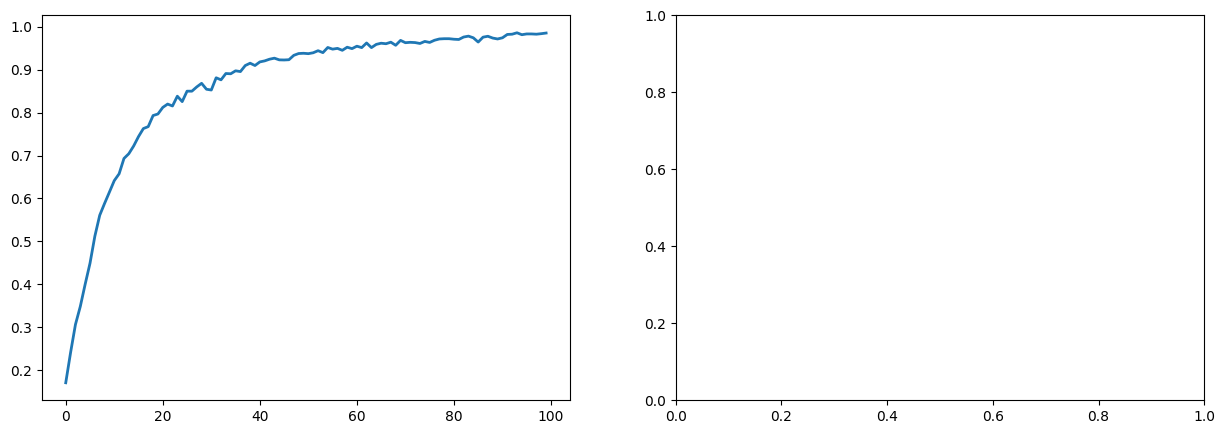

In [13]:
print("\n" + "="*80)
print("TRAIN FINAL MODEL ON FULL TRAIN+VALID DATA")
print("="*80)

# Prepare best configuration
final_config = {
    'window_size': best_overall_config['window_size'],
    'n_features': best_overall_config['n_features'],
    'n_classes': best_overall_config['n_classes'],
    'n_layers': best_overall_config['n_layers'],
    'n_units': best_overall_config['n_units'],
    'dropout_rate': best_overall_config['dropout_rate'],
    'learning_rate': best_overall_config['learning_rate'],
    'bidirectional': best_overall_config['bidirectional'],
    'l2_reg': best_overall_config['l2_reg']
}

print("\nTraining final model with best configuration...")
print(f"Using all {X_train_valid.shape[0]} train+valid samples")

# Create sequences
ws = final_config['window_size']
X_train_final, y_train_final = create_sequences(X_train_valid, y_train_valid, window_size=ws)
X_test_final, y_test_final = create_sequences(X_test_scaled, y_test_encoded, window_size=ws)

print(f"Train sequences: {X_train_final.shape}")
print(f"Test sequences: {X_test_final.shape}")

# Build final model
final_model = build_gru_model(**final_config)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

# Train
print("\nTraining...")
history_final = final_model.fit(
    X_train_final, y_train_final,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_acc = final_model.evaluate(X_test_final, y_test_final)

print(f"\n" + "="*80)
print("FINAL MODEL PERFORMANCE")
print("="*80)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Trained for {len(history_final.history['loss'])} epochs")
print("="*80)

# Plot training history (training only, no validation)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
ax1.plot(history_final.history['accuracy'], linewidth=2, color='blue', label='Training')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Final Model - Training Accuracy', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history_final.history['loss'], linewidth=2, color='orange', label='Training')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Final Model - Training Loss', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# Predictions and confusion matrix
y_pred_probs = final_model.predict(X_test_final, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Overall confusion matrix (8 classes)
plot_confusion_matrix(y_test_final, y_pred, le.classes_, 
                     title="Final Model - Test Set Performance (8 Classes)")

# Save the model
final_model.save('best_model_grade5.h5')
print("\n✓ Model saved as 'best_model_grade5.h5'")

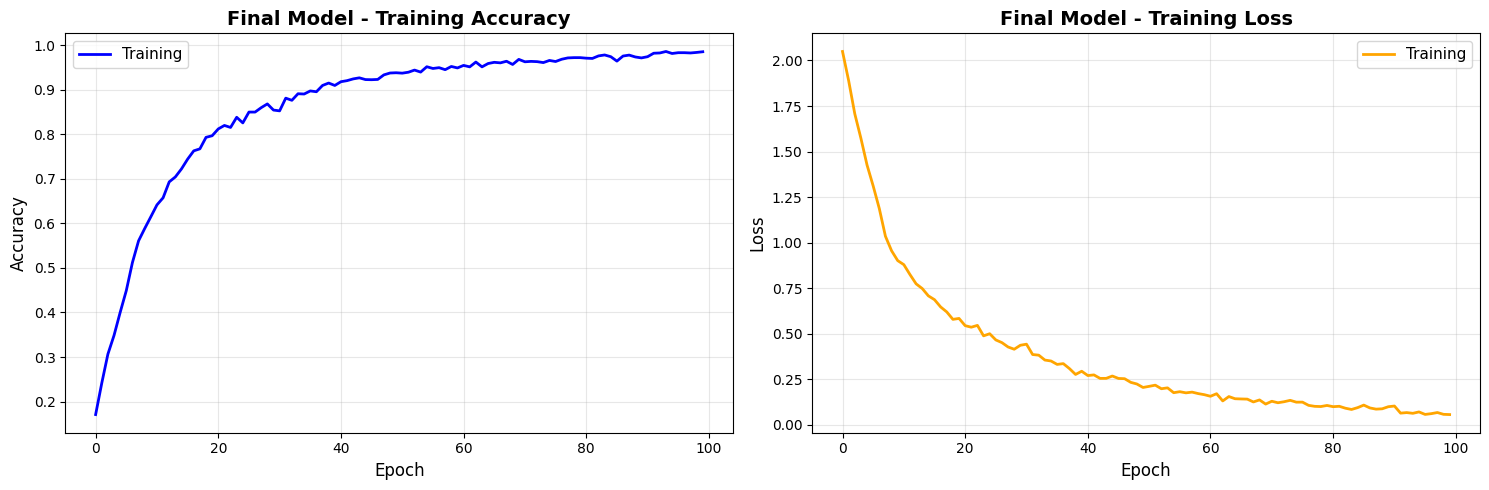

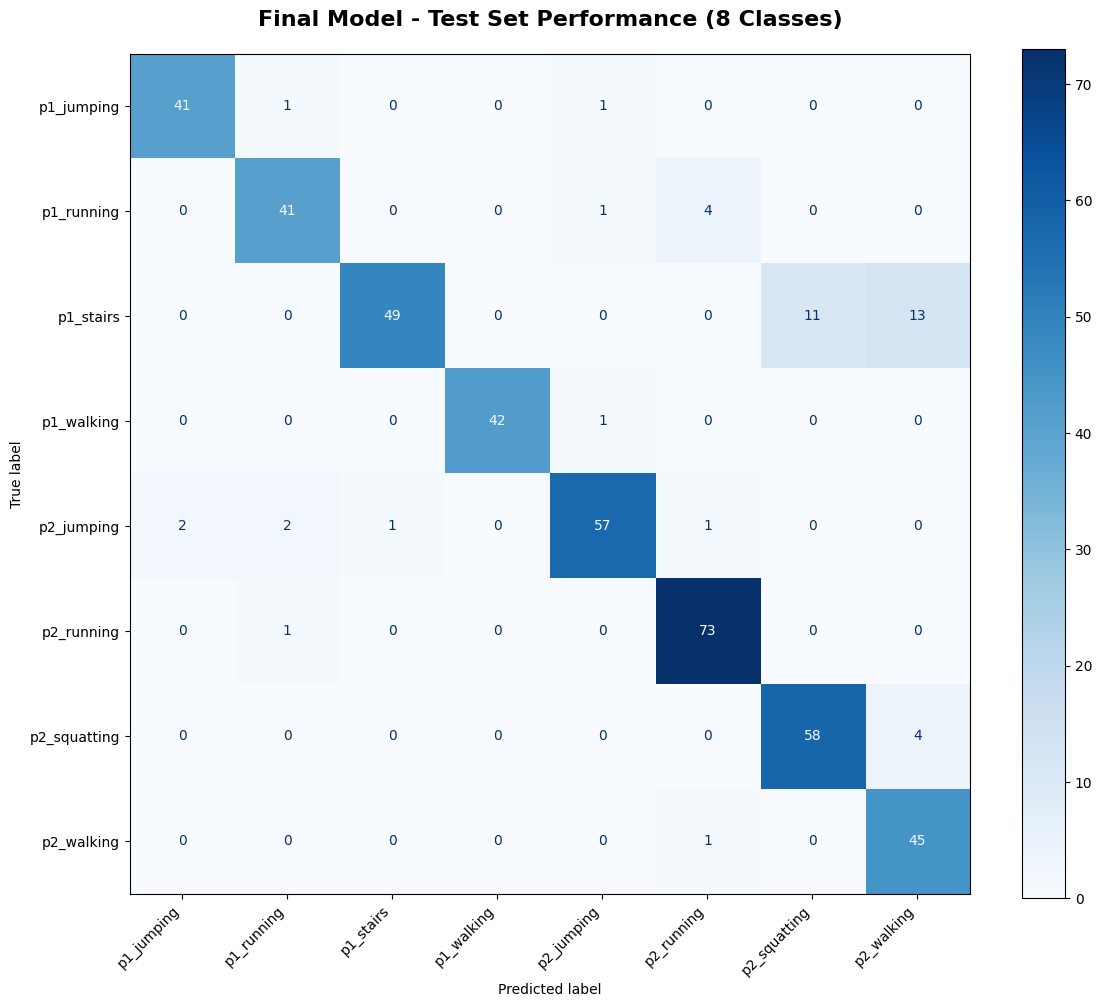


Final Model - Test Set Performance (8 Classes)
              precision    recall  f1-score   support

  p1_jumping       0.95      0.95      0.95        43
  p1_running       0.91      0.89      0.90        46
   p1_stairs       0.98      0.67      0.80        73
  p1_walking       1.00      0.98      0.99        43
  p2_jumping       0.95      0.90      0.93        63
  p2_running       0.92      0.99      0.95        74
p2_squatting       0.84      0.94      0.89        62
  p2_walking       0.73      0.98      0.83        46

    accuracy                           0.90       450
   macro avg       0.91      0.91      0.90       450
weighted avg       0.91      0.90      0.90       450


✓ Model saved as 'best_model_grade5.h5'


/opt/miniconda3/envs/lab3_env/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [14]:
# Plot training history (training only, no validation)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
ax1.plot(history_final.history['accuracy'], linewidth=2, color='blue', label='Training')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Final Model - Training Accuracy', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history_final.history['loss'], linewidth=2, color='orange', label='Training')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Final Model - Training Loss', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# Predictions and confusion matrix
y_pred_probs = final_model.predict(X_test_final, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Overall confusion matrix (8 classes)
plot_confusion_matrix(y_test_final, y_pred, le.classes_, 
                     title="Final Model - Test Set Performance (8 Classes)")

# Save the model
final_model.save('best_model_grade5.h5')
print("\n✓ Model saved as 'best_model_grade5.h5'")

### Analyze Person vs Movement Classification


PERSON vs MOVEMENT CLASSIFICATION ANALYSIS

=== Classification Accuracy Breakdown ===
Person Classification Accuracy: 0.9178
Movement Classification Accuracy: 0.9200
Combined (8-class) Accuracy: 0.9022


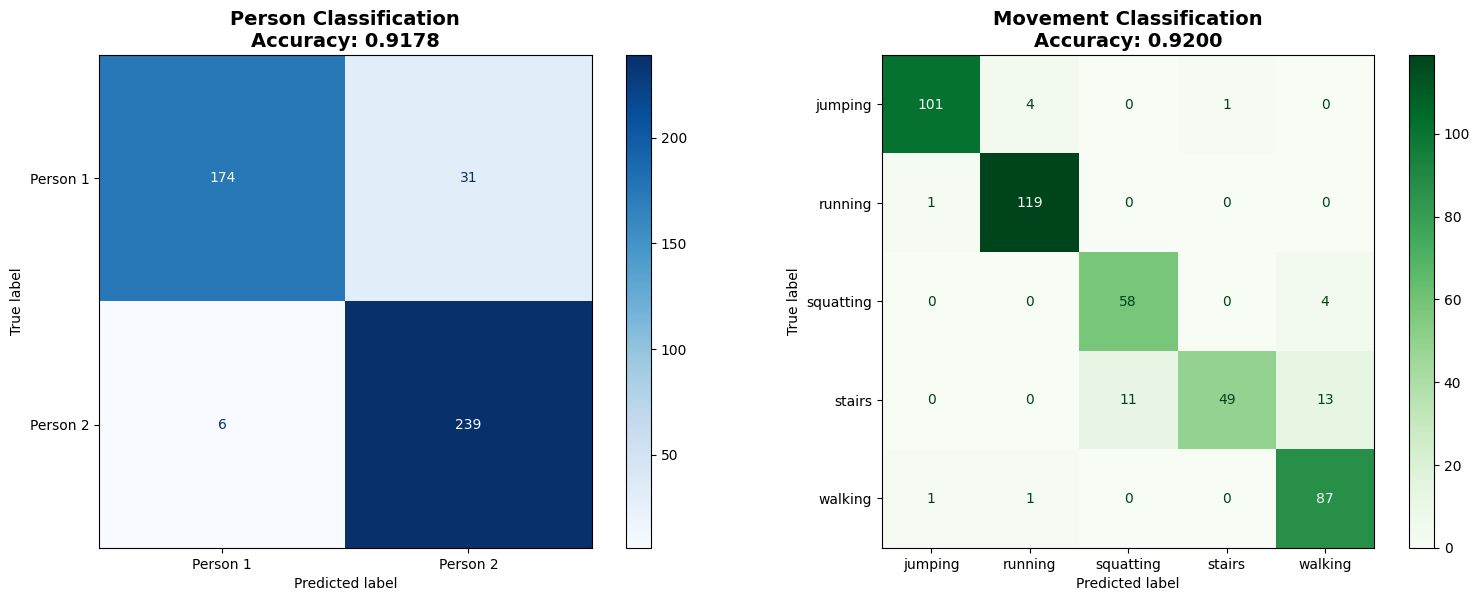


=== Per-Person Movement Classification Accuracy ===
Person 1 (You): 0.8683 (205 samples)
  Movement breakdown:
    jumping: 0.9767 (43 samples)
    running: 0.9783 (46 samples)
    stairs: 0.6712 (73 samples)
    walking: 0.9767 (43 samples)
Person 2 (Person 2): 0.9633 (245 samples)
  Movement breakdown:
    jumping: 0.9365 (63 samples)
    running: 1.0000 (74 samples)
    squatting: 0.9355 (62 samples)
    walking: 0.9783 (46 samples)


In [15]:
print("\n" + "="*80)
print("PERSON vs MOVEMENT CLASSIFICATION ANALYSIS")
print("="*80)

# Extract person and movement from predictions
y_test_person = np.array([le.classes_[i].split('_')[0] for i in y_test_final])
y_test_movement = np.array([le.classes_[i].split('_')[1] for i in y_test_final])

y_pred_person = np.array([le.classes_[i].split('_')[0] for i in y_pred])
y_pred_movement = np.array([le.classes_[i].split('_')[1] for i in y_pred])

# Calculate accuracies
person_acc = accuracy_score(y_test_person, y_pred_person)
movement_acc = accuracy_score(y_test_movement, y_pred_movement)

print(f"\n=== Classification Accuracy Breakdown ===")
print(f"Person Classification Accuracy: {person_acc:.4f}")
print(f"Movement Classification Accuracy: {movement_acc:.4f}")
print(f"Combined (8-class) Accuracy: {test_acc:.4f}")

# Separate confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Person confusion matrix
cm_person = confusion_matrix(y_test_person, y_pred_person)
disp_person = ConfusionMatrixDisplay(confusion_matrix=cm_person, display_labels=['Person 1', 'Person 2'])
disp_person.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title(f'Person Classification\nAccuracy: {person_acc:.4f}', fontsize=14, fontweight='bold')

# Movement confusion matrix
unique_movements = sorted(list(set(y_test_movement)))
cm_movement = confusion_matrix(y_test_movement, y_pred_movement, labels=unique_movements)
disp_movement = ConfusionMatrixDisplay(confusion_matrix=cm_movement, display_labels=unique_movements)
disp_movement.plot(ax=ax2, cmap='Greens', values_format='d')
ax2.set_title(f'Movement Classification\nAccuracy: {movement_acc:.4f}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Per-person movement classification
print("\n=== Per-Person Movement Classification Accuracy ===")
for person_id in ['p1', 'p2']:
    person_name = "Person 1 (You)" if person_id == 'p1' else "Person 2 (Person 2)"
    mask = y_test_person == person_id
    if mask.sum() > 0:
        person_movement_acc = accuracy_score(y_test_movement[mask], y_pred_movement[mask])
        print(f"{person_name}: {person_movement_acc:.4f} ({mask.sum()} samples)")
        
        # Per-class breakdown
        print(f"  Movement breakdown:")
        for movement in unique_movements:
            movement_mask = mask & (y_test_movement == movement)
            if movement_mask.sum() > 0:
                movement_person_acc = accuracy_score(
                    y_test_movement[movement_mask], 
                    y_pred_movement[movement_mask]
                )
                print(f"    {movement}: {movement_person_acc:.4f} ({movement_mask.sum()} samples)")

## Predict on 90-Second Recording


PREDICTION ON 90-SECOND COMBINED RECORDINGS

Person 1 (Your recording):
  Duration: ~119.5 seconds (assuming 100 Hz)
  Samples: 11946


/var/folders/4n/0_8b7vmd7kd3xnvjcp4ck8y40000gn/T/ipykernel_19141/2500628297.py:15: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
/var/folders/4n/0_8b7vmd7kd3xnvjcp4ck8y40000gn/T/ipykernel_19141/2500628297.py:15: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")



Person 2 (Person 2's recording):
  Duration: ~115.2 seconds (assuming 100 Hz)
  Samples: 11515

Predicting on Person 1 (Your) 90-second recording
  Created 477 windows

  Predicted class distribution:
    p1_jumping: 54 windows (11.3%)
    p1_running: 126 windows (26.4%)
    p1_stairs: 134 windows (28.1%)
    p1_walking: 87 windows (18.2%)
    p2_jumping: 24 windows (5.0%)
    p2_running: 52 windows (10.9%)

  Person identification: 401/477 (84.1%)

  Movement distribution:
    jumping: 78 windows (16.4%)
    running: 178 windows (37.3%)
    stairs: 134 windows (28.1%)
    walking: 87 windows (18.2%)


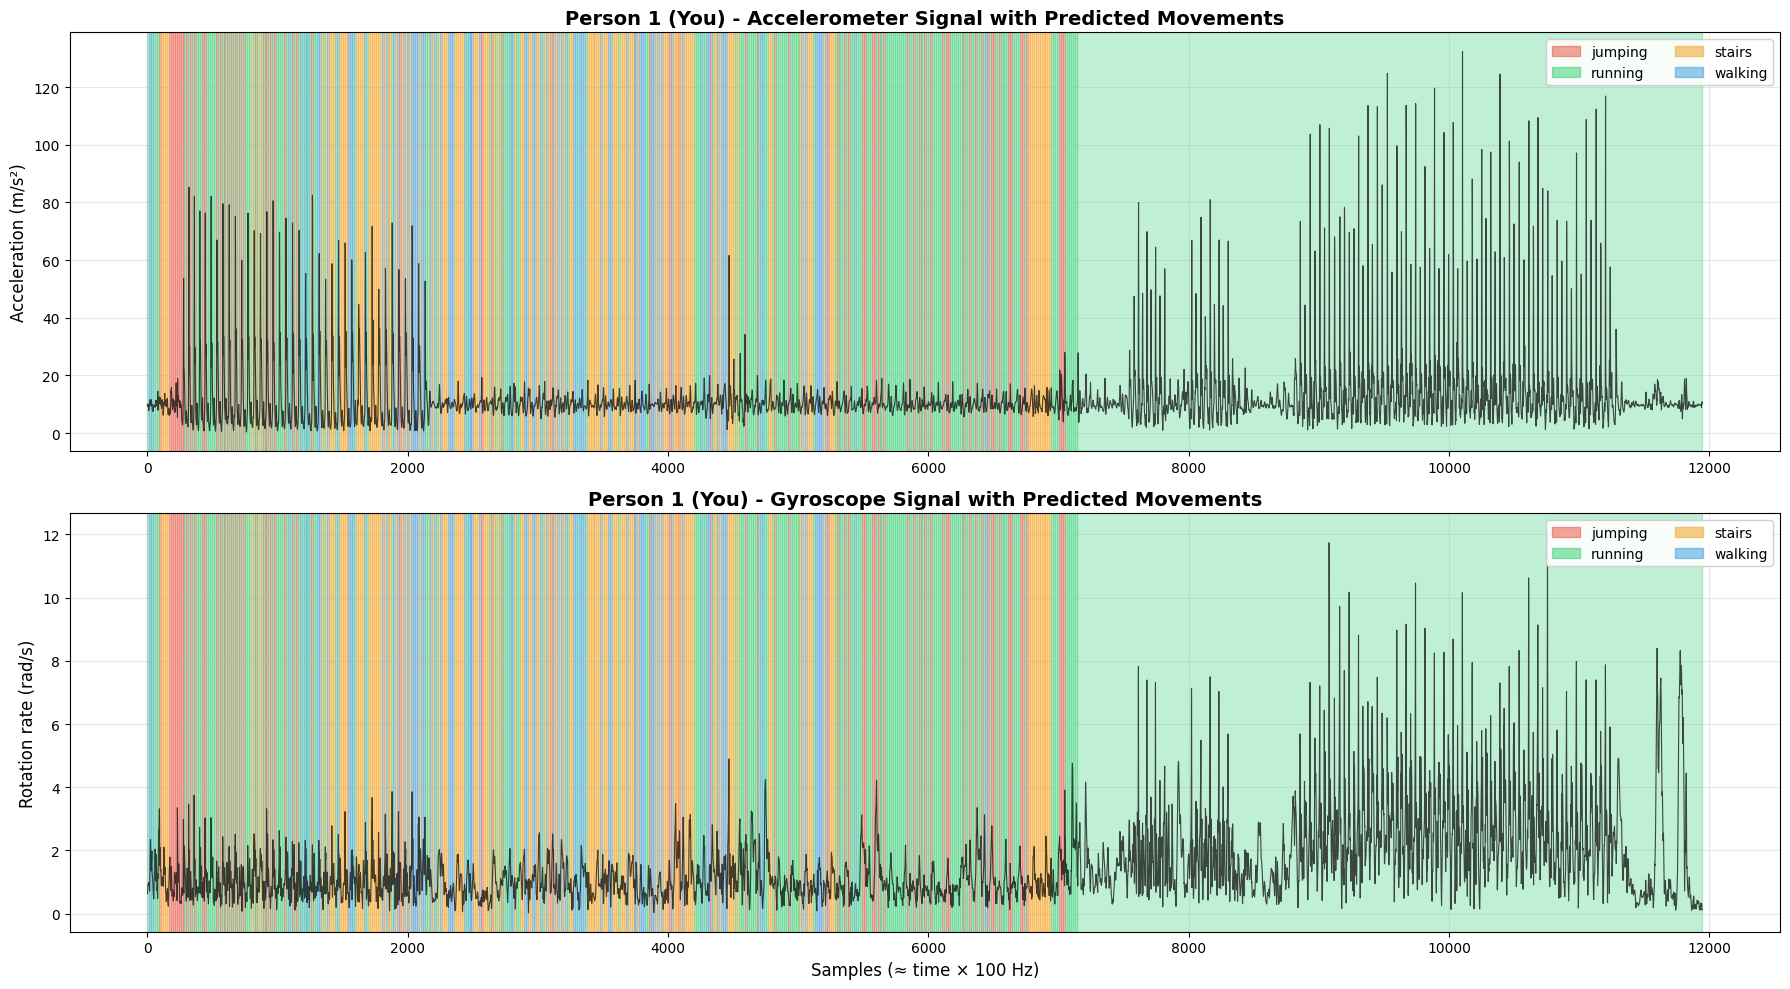


Predicting on Person 2 (Person 2's) 90-second recording
  Created 460 windows

  Predicted class distribution:
    p1_jumping: 51 windows (11.1%)
    p1_running: 54 windows (11.7%)
    p1_stairs: 103 windows (22.4%)
    p1_walking: 78 windows (17.0%)
    p2_jumping: 25 windows (5.4%)
    p2_running: 68 windows (14.8%)
    p2_squatting: 60 windows (13.0%)
    p2_walking: 21 windows (4.6%)

  Person identification: 174/460 (37.8%)

  Movement distribution:
    jumping: 76 windows (16.5%)
    running: 122 windows (26.5%)
    squatting: 60 windows (13.0%)
    stairs: 103 windows (22.4%)
    walking: 99 windows (21.5%)


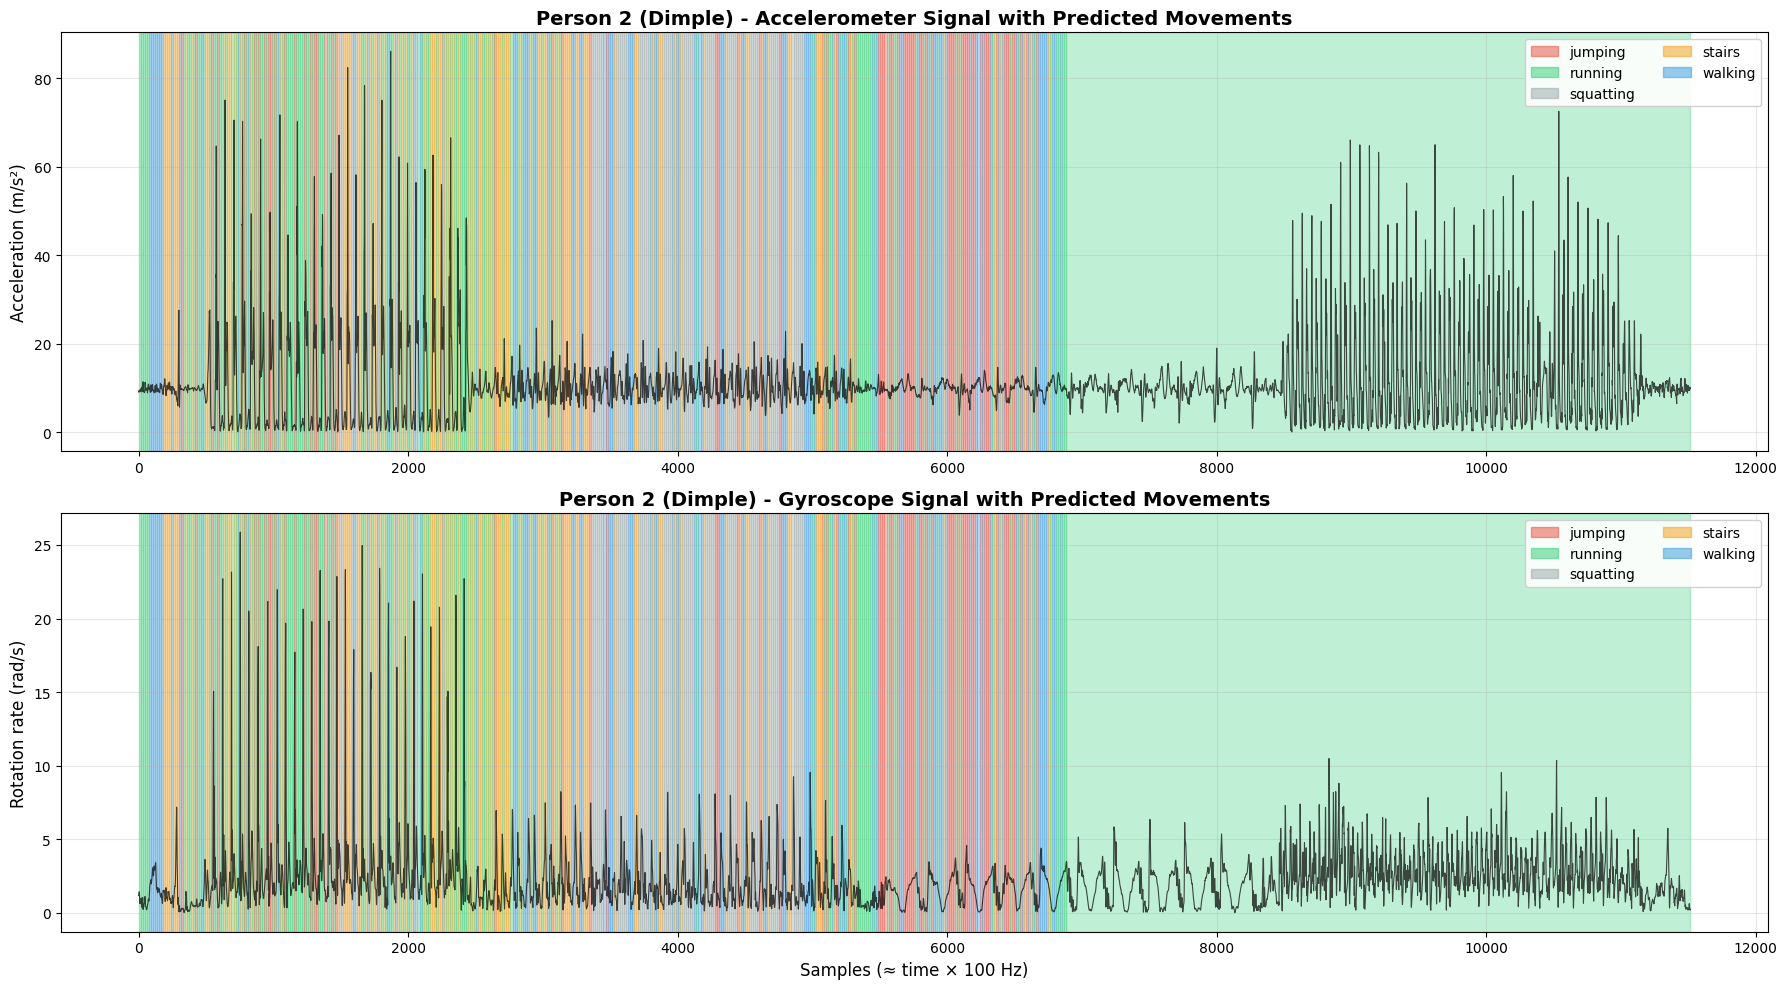

In [16]:
print("\n" + "="*80)
print("PREDICTION ON 90-SECOND COMBINED RECORDINGS")
print("="*80)

def load_and_preprocess_90s_recording(acc_path, gyro_path, person_name):
    """Load and preprocess 90-second recording."""
    def clean_sensor_values(df):
        for col in df.columns:
            if df[col].dtype == object:
                df[col] = (
                    df[col]
                    .str.replace("×10^", "e", regex=False)
                    .str.replace(" ", "", regex=False)
                )
            df[col] = pd.to_numeric(df[col], errors="ignore")
        return df
    
    # Load data
    acc_df = pd.read_csv(acc_path)
    gyro_df = pd.read_csv(gyro_path)
    
    acc_df = clean_sensor_values(acc_df)
    gyro_df = clean_sensor_values(gyro_df)
    
    # Align
    min_len = min(len(acc_df), len(gyro_df))
    acc_df = acc_df.iloc[:min_len]
    gyro_df = gyro_df.iloc[:min_len]
    
    # Combine
    combined_df = pd.concat([
        acc_df[['X (m/s^2)', 'Y (m/s^2)', 'Z (m/s^2)']].rename(columns={
            'X (m/s^2)': 'ax', 'Y (m/s^2)': 'ay', 'Z (m/s^2)': 'az'
        }),
        gyro_df[['X (rad/s)', 'Y (rad/s)', 'Z (rad/s)']].rename(columns={
            'X (rad/s)': 'gx', 'Y (rad/s)': 'gy', 'Z (rad/s)': 'gz'
        })
    ], axis=1)
    
    print(f"\n{person_name}:")
    print(f"  Duration: ~{len(combined_df)/100:.1f} seconds (assuming 100 Hz)")
    print(f"  Samples: {len(combined_df)}")
    
    return combined_df

# Load both 90s recordings
my_combined_df = load_and_preprocess_90s_recording(
    "../pickles/Accelerometer.csv",
    "../pickles/Gyroscope.csv",
    "Person 1 (Your recording)"
)

p2_combined_df = load_and_preprocess_90s_recording(
    "../pickles/Accelerometer_p2.csv",
    "../pickles/Gyroscope_p2.csv",
    "Person 2 (Person 2's recording)"
)

# Function to predict and visualize
def predict_and_visualize(combined_df, person_name, person_id):
    """Predict classes on 90s recording and visualize."""
    # Preprocess
    combined_scaled = scaler.transform(combined_df.values)
    
    # Create sequences
    X_90s, _ = create_sequences(combined_scaled, np.zeros(len(combined_scaled)), window_size=ws)
    print(f"  Created {len(X_90s)} windows")
    
    # Predict
    pred_probs_90s = final_model.predict(X_90s, verbose=0)
    pred_classes_90s = np.argmax(pred_probs_90s, axis=1)
    pred_labels_90s = le.inverse_transform(pred_classes_90s)
    
    # Extract person and movement
    pred_person = np.array([label.split('_')[0] for label in pred_labels_90s])
    pred_movement = np.array([label.split('_')[1] for label in pred_labels_90s])
    
    # Statistics
    print(f"\n  Predicted class distribution:")
    unique, counts = np.unique(pred_labels_90s, return_counts=True)
    for cls, cnt in zip(unique, counts):
        print(f"    {cls}: {cnt} windows ({cnt/len(pred_labels_90s)*100:.1f}%)")
    
    # Person identification accuracy
    correct_person = (pred_person == person_id).sum()
    print(f"\n  Person identification: {correct_person}/{len(pred_person)} ({correct_person/len(pred_person)*100:.1f}%)")
    
    print(f"\n  Movement distribution:")
    unique_mov, counts_mov = np.unique(pred_movement, return_counts=True)
    for mov, cnt in zip(unique_mov, counts_mov):
        print(f"    {mov}: {cnt} windows ({cnt/len(pred_movement)*100:.1f}%)")
    
    # Visualize
    acc_mag = np.sqrt((combined_df[['ax','ay','az']]**2).sum(axis=1))
    gyro_mag = np.sqrt((combined_df[['gx','gy','gz']]**2).sum(axis=1))
    
    # Create color map
    movement_colors = {
        'jumping': '#e74c3c',
        'walking': '#3498db',
        'running': '#2ecc71',
        'stairs': '#f39c12',
        'squating': '#9b59b6'
    }
    
    # Compute segment boundaries
    segment_edges = np.arange(len(pred_movement)) * (ws // 2)
    segment_edges = np.append(segment_edges, len(acc_mag))
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10))
    
    # Accelerometer
    ax1.plot(acc_mag, color='black', alpha=0.7, linewidth=0.8)
    for i, mov in enumerate(pred_movement):
        color = movement_colors.get(mov, '#95a5a6')
        ax1.axvspan(segment_edges[i], segment_edges[i+1], color=color, alpha=0.3)
    ax1.set_ylabel('Acceleration (m/s²)', fontsize=12)
    ax1.set_title(f'{person_name} - Accelerometer Signal with Predicted Movements', 
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Legend
    handles = [plt.Rectangle((0,0),1,1, color=movement_colors.get(m, '#95a5a6'), alpha=0.5) 
               for m in sorted(unique_mov)]
    ax1.legend(handles, sorted(unique_mov), loc='upper right', framealpha=0.9, ncol=2)
    
    # Gyroscope
    ax2.plot(gyro_mag, color='black', alpha=0.7, linewidth=0.8)
    for i, mov in enumerate(pred_movement):
        color = movement_colors.get(mov, '#95a5a6')
        ax2.axvspan(segment_edges[i], segment_edges[i+1], color=color, alpha=0.3)
    ax2.set_xlabel('Samples (≈ time × 100 Hz)', fontsize=12)
    ax2.set_ylabel('Rotation rate (rad/s)', fontsize=12)
    ax2.set_title(f'{person_name} - Gyroscope Signal with Predicted Movements', 
                  fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(handles, sorted(unique_mov), loc='upper right', framealpha=0.9, ncol=2)
    
    plt.tight_layout()
    plt.show()

# Predict on both recordings
print("\n" + "="*80)
print("Predicting on Person 1 (Your) 90-second recording")
print("="*80)
predict_and_visualize(my_combined_df, "Person 1 (You)", "p1")

print("\n" + "="*80)
print("Predicting on Person 2 (Person 2's) 90-second recording")
print("="*80)
predict_and_visualize(p2_combined_df, "Person 2 (Person 2)", "p2")